In [1]:
%pip install --upgrade tensorflow
%pip install plotly
%pip install neuralprophet
%pip install plotly-resampler
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Spanish Real Estate Forecasting - Data Model Training
# This notebook is dedicated to training a predictive model for forecasting real estate prices in Spain. 
# I will use the cleaned dataset to train a machine learning model, evaluate its performance, and make predictions.

# Importing necessary libraries for data manipulation, visualization, and machine learning
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from sklearn.preprocessing import StandardScaler
import sys
import torch
import plotly
# import neuralprophet.configure as np_config
# Fix para PyTorch 2.6+ con NeuralProphet
#torch.serialization.add_safe_globals([
    #np_config.ConfigSeasonality,
    #np_config.ConfigEvents,
    #np_config.ConfigLaggedRegressors,
    #np_config.ConfigFutureRegressors
#])
from xgboost import plot_importance

BASE_DIR_SYS = Path.cwd().parent.parent

sys.path.append(str(BASE_DIR_SYS))

from src.models.prophet_model import NeuralProphetModel
from src.models.xgboost_model import XGBoostModel

import warnings
import logging

# utureWarning de pandas (Series.view deprecado)
warnings.filterwarnings("ignore", category=FutureWarning)

# Warnings internos de NeuralProphet
logging.getLogger("NP.forecaster").setLevel(logging.ERROR)
logging.getLogger("NP.df_utils").setLevel(logging.ERROR)
logging.getLogger("NP.config").setLevel(logging.ERROR)

# Warnings de PyTorch Lightning
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

# Warnings generales de Python 
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
# Loading the cleaned dataset from the pickle file for analysis
BASE_DIR = Path.cwd().parent.parent
data_path = BASE_DIR / "data" / "cleaned_real_estate_data.pkl"
df = pd.read_pickle(data_path)
df.sample(5)

,ano,trim,geo,cod-ca,ca,cod-prv,prv,sector,variable,valor,tipo,metrica
162671,2020,4,comunidad,7,castilla y leon,98,castilla y leon,commercial,nav-pm2,355.24,nav,pm2
137051,2007,4,provincia,8,castilla-la mancha,13,ciudad real,commercial,nav-num,137.00,nav,num
161888,2018,1,provincia,7,castilla y leon,49,zamora,commercial,nav-pm2,254.15,nav,pm2
160262,2012,2,comunidad,16,pais vasco,98,pais vasco,commercial,nav-pm2,817.78,nav,pm2
140452,2019,3,provincia,12,galicia,15,a coruna,commercial,nav-num,152.00,nav,num


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82080 entries, 0 to 164159
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ano       82080 non-null  int64  
 1   trim      82080 non-null  int64  
 2   geo       82080 non-null  object 
 3   cod-ca    82080 non-null  int64  
 4   ca        82080 non-null  object 
 5   cod-prv   82080 non-null  int64  
 6   prv       82080 non-null  object 
 7   sector    82080 non-null  object 
 8   variable  82080 non-null  object 
 9   valor     82080 non-null  float64
 10  tipo      82080 non-null  object 
 11  metrica   82080 non-null  object 
dtypes: float64(1), int64(4), object(7)
memory usage: 8.1+ MB


*PREPARING THE DATA FOR FORECASTING*

In [5]:
# Converting categorical columns to the appropriate data type to optimize memory usage and improve performance during modeling.
cat_cols = [
    "geo",
    "ca",
    "prv",
    "sector",
    "variable",
    "tipo",
    "metrica"
]

for col in cat_cols:
    df[col] = df[col].astype("category")

# Specifically converting "cod-ca" and "cod-prv" to categorical data types as they represent categorical information 
# about the autonomous communities and provinces in Spain.
df["cod-ca"] = df["cod-ca"].astype("category")
df["cod-prv"] = df["cod-prv"].astype("category")

In [6]:
# Creating a datetime column from the "ano" and "trim" columns to facilitate time series analysis and modeling.
df["date"] = pd.PeriodIndex.from_fields(year=df["ano"], quarter=df["trim"], freq="Q").to_timestamp()
df = df.sort_values("date")

In [7]:
# Exploring the average property value over time to identify trends and seasonality in the real estate market.
ts = (
    df.groupby(
        ["date", "tipo"],
        observed = True)
        ["valor"]
        .mean()
        .reset_index()
)

In [8]:
# Applying log transformation to the average property values in the time series data 
# to reduce skewness and make the data more suitable for modeling. It helps to stabilize the variance 
# and improve the performance of machine learning algorithms.
ts["valor_log"] = np.log1p(ts["valor"])

In [9]:
# Extracting year and quarter from the date column to create additional features for time series analysis and modeling.
ts["year"] = ts["date"].dt.year
ts["quarter"] = ts["date"].dt.quarter
ts["quarter_sin"] = np.sin(2*np.pi*ts["quarter"]/4)
ts["quarter_cos"] = np.cos(2*np.pi*ts["quarter"]/4)

In [10]:
# Creating lag features to capture the temporal dependencies in the time series data, 
# which can help improve the performance of predictive models by providing information about past values.
ts["lag_1"] = ts["valor_log"].shift(1)
ts["lag_2"] = ts["valor_log"].shift(2)
ts["lag_4"] = ts["valor_log"].shift(4)
ts["lag_8"] = ts["valor_log"].shift(8)

In [11]:
# Creating rolling mean and standard deviation features to capture the local trends and volatility in the time series data,
# which can help improve the performance of predictive models by providing information about recent patterns.
ts["rolling_mean_4"] = (ts.groupby("tipo", observed=True)["valor_log"].transform(lambda x: x.rolling(4).mean()))
ts["rolling_std_4"] = (ts.groupby("tipo", observed=True)["valor_log"].transform(lambda x: x.rolling(4).std()))
ts["rolling_mean_8"] = (ts.groupby("tipo", observed=True)["valor_log"].transform(lambda x: x.rolling(8).mean()))
ts["rolling_std_8"] = (ts.groupby("tipo", observed=True)["valor_log"].transform(lambda x: x.rolling(8).std()))
ts["diff_1"] = ts["valor_log"].diff(1)
ts["diff_4"] = ts["valor_log"].diff(4)
ts["diff_8"] = ts["valor_log"].diff(8)
q1 = df["valor"].quantile(0.01)
q99 = df["valor"].quantile(0.99)
df["valor"] = df["valor"].clip(q1, q99)


In [12]:
# Dropping rows with missing values that were introduced by the lag and rolling features,
# which are necessary for training the predictive model without errors.
ts = ts.dropna()

In [13]:
# Dividing the time series data into training and testing sets based on a specific date 
# to evaluate the performance of the predictive model on unseen data.
train = ts[ts["date"] < "2023-01-01"]
test = ts[ts["date"] >= "2023-01-01"]

In [14]:
# Encoding the "tipo" categorical variable using one-hot encoding to convert it into a format that can be used by machine learning algorithms,
# while dropping the first category to avoid multicollinearity.
train = pd.get_dummies(train, columns=["tipo"], drop_first=True)
test = pd.get_dummies(test, columns=["tipo"], drop_first=True)

# Aligning the training and testing datasets to ensure they have the same columns after one-hot encoding,
# filling any missing columns with zeros to maintain consistency for model training and evaluation.
train, test = train.align(test, join="left", axis=1, fill_value=0)

In [15]:
# Scaling the features using StandardScaler to normalize the data by ensuring that all features are on a similar scale.
scaler = StandardScaler()
feature_cols = [
"lag_1", 
"lag_2",   
"lag_4",
"lag_8",    
"rolling_mean_4",    
"rolling_std_4",
"rolling_mean_8",
"rolling_std_8",    
"quarter_sin",    
"quarter_cos"]
target_col = "valor_log" # The target variable for modeling is the log-transformed average property value.
train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols] = scaler.transform(test[feature_cols])

# Preparing the training and testing datasets by separating the features and target variable for model training and evaluation.
X_train = train.drop(columns=["valor", "valor_log", "date"])
y_train = train[target_col]
X_test = test.drop(columns=["valor", "valor_log", "date"])
y_test = test[target_col]

In [16]:
# Identifying the type of property (loc, nav, tras, viv) based on the one-hot encoded columns to create a new "tipo" column 
# that categorizes the properties for further analysis and modeling.
def get_tipo(row):
    if row["tipo_loc"]:  return "loc"
    if row["tipo_nav"]:  return "nav"
    if row["tipo_tras"]: return "tras"
    if row["tipo_viv"]:  return "viv"
    return "unknown"

train["tipo"] = train.apply(get_tipo, axis=1)
test["tipo"]  = test.apply(get_tipo, axis=1)

# Training and evaluating a NeuralProphet model for each property type to capture the unique 
# patterns and trends in the real estate market for different types of properties.
np_models = {}
np_maes   = {}

for tipo in ["loc", "nav", "tras", "viv"]:
    train_tipo = train[train["tipo"] == tipo]
    test_tipo  = test[test["tipo"] == tipo]

    model = NeuralProphetModel()
    model.fit(train_tipo)
    model.predict(periods=len(test_tipo))
    mae = model.evaluate(test_tipo)

    np_models[tipo] = model
    np_maes[tipo]   = mae
    print(f"NeuralProphet | Tipo {tipo:4s} — MAE: {mae:.2f}")

print(f"\nNeuralProphet | MAE promedio: {np.mean(list(np_maes.values())):.2f}")

prophet_model = NeuralProphetModel()

# Agregar la serie temporal por fecha para evitar valores duplicados en ds
train_agg = (
    train[["date", target_col]]
    .groupby("date", observed=True)
    .mean()
    .reset_index()
)
test_agg = (
    test[["date", target_col]]
    .groupby("date", observed=True)
    .mean()
    .reset_index()
)

train_agg = train_agg.drop_duplicates(subset=["date"])
test_agg = test_agg.drop_duplicates(subset=["date"])

prophet_model.fit(train_agg)
predictions = prophet_model.predict(periods=len(test_agg))
mae = prophet_model.evaluate(test_agg)
print(f"Mean Absolute Error: {mae}")
predictions = prophet_model.predict(periods = len(test))
mae = prophet_model.evaluate(test)
print(f"Mean Absolute Error: {mae}")

Training: 0it [00:00, ?it/s]

INFO - (NP.data.processing._handle_missing_data) - Dropped 12 rows at the end with NaNs in 'y' column.


Predicting: 8it [00:00, ?it/s]

NeuralProphet | Tipo loc  — MAE: 4480.74


Training: 0it [00:00, ?it/s]

...

Predicting: 8it [00:00, ?it/s]

INFO - (NP.data.processing._handle_missing_data) - Dropped 60 rows at the end with NaNs in 'y' column.


Mean Absolute Error: 338.8982979128062


Predicting: 8it [00:00, ?it/s]

Mean Absolute Error: 37570.60610508295


In [17]:
# Visualizing the components of the Prophet model to understand the underlying patterns in the time series data,
# such as trends and seasonality, which can provide insights into the factors driving real estate prices in Spain.
prophet_model.model.plot_components(predictions)

FigureWidgetResampler({
    'data': [{'line': {'color': '#2d92ff', 'width': 2},
              'mode': 'lines',
              'name': 'Trend',
              'showlegend': False,
              'type': 'scatter',
              'uid': '07a9f969-e1f2-44a3-91e8-0f8e4a3e53e7',
              'x': array([datetime.datetime(2008, 10, 1, 0, 0),
                          datetime.datetime(2009, 1, 1, 0, 0),
                          datetime.datetime(2009, 4, 1, 0, 0),
                          datetime.datetime(2009, 7, 1, 0, 0),
                          datetime.datetime(2009, 10, 1, 0, 0),
                          datetime.datetime(2010, 1, 1, 0, 0),
                          datetime.datetime(2010, 4, 1, 0, 0),
                          datetime.datetime(2010, 7, 1, 0, 0),
                          datetime.datetime(2010, 10, 1, 0, 0),
                          datetime.datetime(2011, 1, 1, 0, 0),
                          datetime.datetime(2011, 4, 1, 0, 0),
                          datetim

In [18]:
prophet_model.save_model("prophet_model.pkl")

In [19]:
xgb_model = XGBoostModel()

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
mae = xgb_model.evaluate(y_test)
print(f"XGBoost MAE: {mae}")

XGBoost MAE: 1948.4707045355888


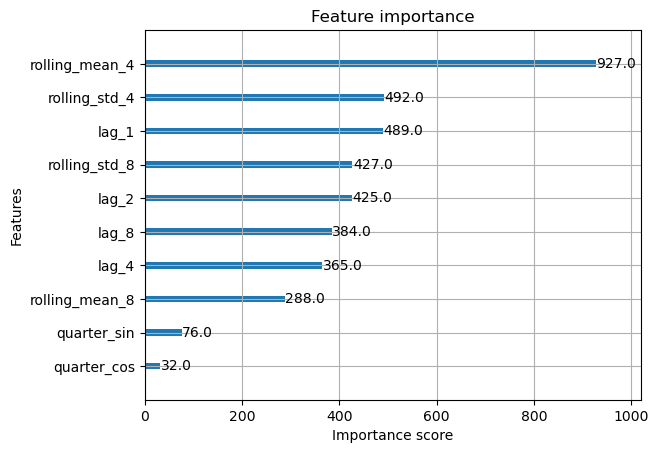

In [20]:
plot_importance(xgb_model.model)
plt.show()

In [21]:
xgb_model.save_model("xgboost_model.json")